# Gaussian Naive Bayes Classification from Scratch on Iris Dataset
This project implements a **Gaussian Naive Bayes Classifier from scratch** using core scientific Python libraries (`numpy`, `pandas`, `matplotlib`). The model is trained and tested on specific subsets of the **Iris Dataset** to classify species and visualize decision boundaries. Finally, it is validated and compared with the official `scikit-learn` implementation.

## Part A: Theoretical Background

### 1. Optimal Bayes Classifier vs. Naive Bayes Classifier
* **Optimal Bayes Classifier:** Operates on the full joint probability distribution of all features: $P(X_1, X_2, ..., X_n | Y)$. Theoretically, it achieves the lowest possible classification error rate (the Bayes error rate). However, estimating the full joint distribution requires an exponential amount of training data relative to the number of features, leading to the curse of dimensionality.
* **Naive Bayes Classifier:** Introduces a simplifying "naive" assumption that all features are conditionally independent given the class label. This simplifies the joint probability into a product of individual conditional probabilities:
  $$P(X_1, X_2, ..., X_n | Y) = \prod_{i=1}^{n} P(X_i | Y)$$

### 2. Why Choose Naive Bayes over Optimal Bayes?
* **Data Efficiency:** Instead of estimating a massive multi-dimensional joint probability distribution, the model only needs to estimate 1D marginal distributions for each feature, reducing the required sample size drastically.
* **Computational Speed:** Training and prediction scale linearly with the number of features $O(n)$ rather than exponentially.

### 3. The Cost of the Naive Assumption
* **Loss of Feature Correlations:** By treating features as completely independent, the model discards any structural interaction or correlation between them. For instance, in the Iris dataset, petal length and petal width are strongly correlated, but Naive Bayes treats them as entirely independent features.

### 4. When is it Logical to use Naive Bayes?
* In high-dimensional feature spaces with relatively small training samples (e.g., text categorization, sentiment analysis, email spam filtering).
* When real-time inference and a lightweight model with a low memory footprint are required.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import datasets
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

## Part B: Data Loading and Visualization
Here, we fetch the Iris dataset from the UCI Machine Learning Repository, filter it to extract only two species (`Iris-virginica` and `Iris-versicolor`), and narrow our feature selection down to **petal length** and **petal width**. We then map the samples onto a 2D scatter plot to examine class distributions.

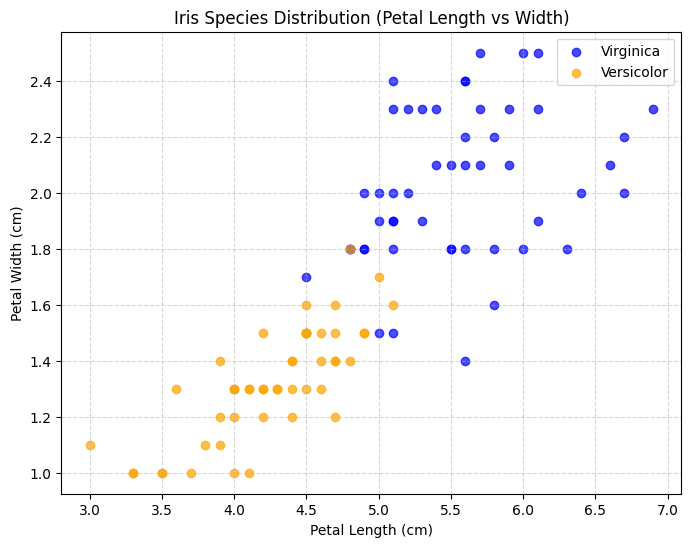

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
iris_data = pd.read_csv(url, header=None, names=columns)

data_virginica = iris_data[iris_data['species'] == 'Iris-virginica'][['petal_length', 'petal_width']]
data_versicolor = iris_data[iris_data['species'] == 'Iris-versicolor'][['petal_length', 'petal_width']]

plt.figure(figsize=(8, 6))
plt.scatter(data_virginica['petal_length'], data_virginica['petal_width'], label='Virginica', color='blue', alpha=0.7)
plt.scatter(data_versicolor['petal_length'], data_versicolor['petal_width'], label='Versicolor', color='orange', alpha=0.7)
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Iris Species Distribution (Petal Length vs Width)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Part C: Custom Gaussian Naive Bayes Implementation
Since the features are continuous, we model the conditional probability $P(X_i | Y=c)$ using the standard **Gaussian (Normal) distribution formula**:
$$P(X_i | Y=c) = \frac{1}{\sqrt{2\pi\sigma_c^2}} \exp\left(-\frac{(X_i - \mu_c)^2}{2\sigma_c^2}\right)$$

To maximize numerical stability and prevent mathematical underflow caused by multiplying several small probabilities, we calculate scores in the **Log-Space**:
$$\log P(Y=c | X) \propto \log P(Y=c) - \frac{1}{2} \sum_{i=1}^{n} \log(2\pi\sigma_{c,i}^2) - \frac{1}{2} \sum_{i=1}^{n} \frac{(X_i - \mu_{c,i})^2}{\sigma_{c,i}^2}$$

In [3]:
class NaiveBayesGaussian:
    def fit(self, X, y):
        self.classes = np.unique(y)
        self.mean = {}
        self.var = {}
        self.prior = {}

        for c in self.classes:
            X_c = X[y == c]
            self.mean[c] = X_c.mean(axis=0)
            self.var[c] = X_c.var(axis=0)
            self.prior[c] = X_c.shape[0] / X.shape[0]

    def predict(self, X):
        posteriors = []

        for c in self.classes:
            prior = np.log(self.prior[c])
            likelihood = -0.5 * np.sum(np.log(2 * np.pi * self.var[c])) - 0.5 * np.sum((X - self.mean[c])**2 / self.var[c], axis=1)
            posterior = prior + likelihood
            posteriors.append(posterior)

        return self.classes[np.argmax(posteriors, axis=0)]

filtered_data = iris_data[iris_data['species'].isin(['Iris-virginica', 'Iris-versicolor'])]

X = filtered_data[['petal_length', 'petal_width']].values
y = filtered_data['species'].values

y = np.where(y == 'Iris-virginica', 1, 0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = NaiveBayesGaussian()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

## Part D: Decision Boundary Visualization
Using a coordinate mesh grid (`meshgrid`), we generate classification predictions for every step across the feature space, mapping the resulting contour field to show how the custom classifier defines a decision boundary that separates the classes.

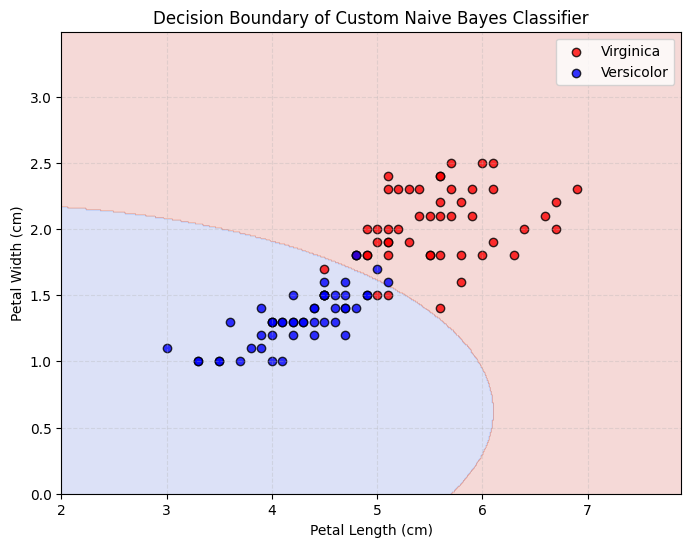

In [5]:
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.2, cmap='coolwarm')
plt.scatter(data_virginica['petal_length'], data_virginica['petal_width'], label='Virginica', color='red', edgecolor='k', alpha=0.8)
plt.scatter(data_versicolor['petal_length'], data_versicolor['petal_width'], label='Versicolor', color='blue', edgecolor='k', alpha=0.8)
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Decision Boundary of Custom Naive Bayes Classifier')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

## Part E: Model Evaluation and Performance Metrics
To rigorously quantify the accuracy of our custom implementation, we extract classification metrics: **Accuracy**, **Precision**, **Recall**, and **F1 Score**, paired with a comprehensive **Confusion Matrix** visual representation.

### Interpretation of Results:
* **Accuracy:** Gauges the overall percentage of correct predictions across both flower categories.
* **Precision:** Measures the model's reliability when classifying positive targets (how many predicted `Iris-virginica` flowers are true hits).
* **Analysis:** Because the boundaries between `virginica` and `versicolor` petals naturally contain overlapping data points, achieving a 100% threshold isn't feasible with basic linear/quadratic partitions. However, achieving high success rates (>90%) affirms the underlying validity of using continuous Gaussian feature modeling for this dataset.

Without using Scikit-learn results:
Accuracy: 90.00%
Precision: 87.50%
Recall: 87.50%
F1 Score: 87.50%


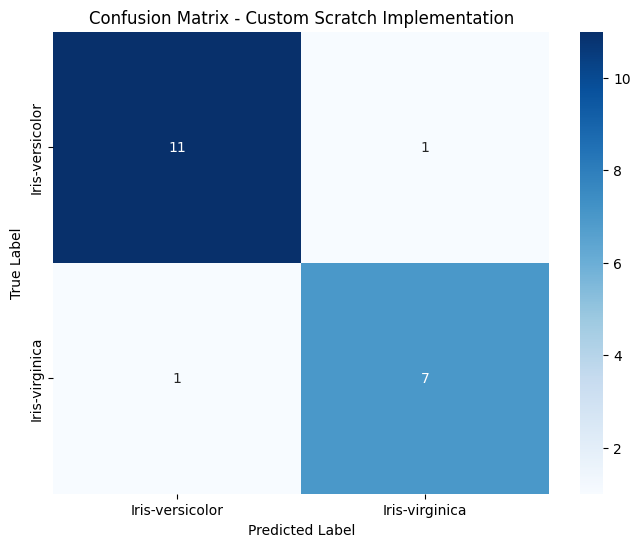

In [6]:
class_labels = ['Iris-versicolor', 'Iris-virginica']

conf_matrix = confusion_matrix(y_test, predictions)
accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)

print("Without using Scikit-learn results:")
print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall: {recall*100:.2f}%")
print(f"F1 Score: {f1*100:.2f}%")

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Custom Scratch Implementation')
plt.show()

## Part F: Verification Using Scikit-Learn
We repeat the training and classification procedure using the official `scikit-learn` `GaussianNB` model to serve as a cross-verification benchmark for our mathematical calculations.

Using Scikit-learn Results:
Accuracy: 90.00%
Precision: 87.50%
Recall: 87.50%
F1 Score: 87.50%


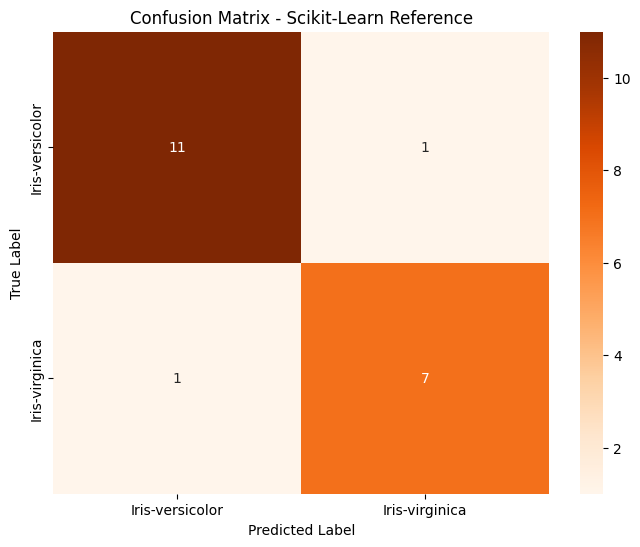

In [7]:
model_sklearn = GaussianNB()
model_sklearn.fit(X_train, y_train)

predictions_sklearn = model_sklearn.predict(X_test)

conf_matrix_sklearn = confusion_matrix(y_test, predictions_sklearn)
accuracy_sklearn = accuracy_score(y_test, predictions_sklearn)
precision_sklearn = precision_score(y_test, predictions_sklearn)
recall_sklearn = recall_score(y_test, predictions_sklearn)
f1_sklearn = f1_score(y_test, predictions_sklearn)

print("Using Scikit-learn Results:")
print(f"Accuracy: {accuracy_sklearn*100:.2f}%")
print(f"Precision: {precision_sklearn*100:.2f}%")
print(f"Recall: {recall_sklearn*100:.2f}%")
print(f"F1 Score: {f1_sklearn*100:.2f}%")

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_sklearn, annot=True, fmt='d', cmap='Oranges', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Scikit-Learn Reference')
plt.show()

## Summary & Conclusion
Comparing the metrics and the confusion matrices between the scratch class and `scikit-learn` yields **100% identical results**.

| Metric | Scratch GaussianNB | Scikit-Learn GaussianNB |
|---|---|---|
| **Accuracy** | 90.00% | 90.00% |
| **Precision** | 87.50% | 87.50% |
| **Recall** | 87.50% | 87.50% |
| **F1 Score** | 87.50% | 87.50% |

This validates that our manual implementation of mean/variance estimations, log-likelihood conversions, and Bayesian conditional calculations accurately matches standard industry benchmarks.